In [47]:
!pip install openpyxl -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
from google.colab import files
import io

In [48]:
# Upload sample.xlsx first, then cve_epss.csv
print("Upload sample.xlsx first, then cve_epss.csv")
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.xlsx'):
        kev_df = pd.read_excel(io.BytesIO(uploaded[fname]))
        print(f"KEV data: {len(kev_df)} rows")
    elif fname.endswith('.csv'):
        epss_df = pd.read_csv(io.BytesIO(uploaded[fname]))
        print(f"EPSS data: {len(epss_df)} rows")

print(kev_df[['CVE ID', 'Vendor', 'Tactic(s)', 'CWE(s)']].head(3).to_string())
print(epss_df[['cve_id','base_severity','base_score','epss_score','impact_score']].head(3).to_string())

Upload sample.xlsx first, then cve_epss.csv


Saving sample.xlsx to sample (6).xlsx
Saving cve_epss.csv to cve_epss (6).csv
KEV data: 1539 rows
EPSS data: 155852 rows
           CVE ID      Vendor                                                           Tactic(s)                                                              CWE(s)
0  CVE-2021-22054     Omnissa                                     Initial Access; Defense Evasion                        CWE-918 (Server-Side Request Forgery (SSRF))
1  CVE-2025-26399  SolarWinds                                           Execution; Initial Access                         CWE-502 (Deserialization of Untrusted Data)
2   CVE-2026-1603      Ivanti  Defense Evasion; Persistence; Privilege Escalation; Initial Access  CWE-288 (Authentication Bypass Using an Alternate Path or Channel)
           cve_id base_severity  base_score  epss_score  impact_score
0   CVE-1999-0199      CRITICAL         9.8     0.00677           5.9
1  CVE-2002-20001          HIGH         7.5     0.11632           3.6
2   C

In [49]:
# Normalize CVE IDs and join both datasets on CVE ID to pair each vuln with its risk scores
kev_df['cve_id'] = kev_df['CVE ID'].str.strip().str.upper()
epss_df['cve_id'] = epss_df['cve_id'].str.strip().str.upper()

merged = kev_df.merge(
    epss_df[['cve_id','base_score','base_severity','epss_score','impact_score',
             'exploitability_score','attack_vector','attack_complexity']],
    on='cve_id',
    how='left'
)

matched = merged['epss_score'].notna().sum()
print(f"Joined datasets — {matched} of {len(merged)} KEV entries matched CVSS data ({matched/len(merged):.1%})")

Joined datasets — 989 of 1539 KEV entries matched CVSS data (64.3%)


In [50]:
# Risk formula: EPSS (exploit probability) × CVSS Impact (severity ÷ 10) × IBM avg breach cost ($4.44M, 2025)
# This gives a per-CVE dollar estimate of expected financial exposure
IBM_AVG_BREACH_COST = 4_440_000

merged['epss_score'] = merged['epss_score'].fillna(merged['epss_score'].median())
merged['impact_score'] = merged['impact_score'].fillna(merged['impact_score'].median())

merged['financial_risk_usd'] = (
    merged['epss_score'] *
    (merged['impact_score'] / 10) *
    IBM_AVG_BREACH_COST
)

print("Top 10 highest-risk CVEs:")
top_risk = merged[['cve_id','Vendor','base_severity','epss_score',
                   'impact_score','financial_risk_usd']].nlargest(10, 'financial_risk_usd')
print(top_risk.to_string(index=False))

Top 10 highest-risk CVEs:
        cve_id    Vendor base_severity  epss_score  impact_score  financial_risk_usd
CVE-2022-22947    VMware      CRITICAL     0.94474           6.0          2516787.36
CVE-2021-22205    GitLab      CRITICAL     0.94467           6.0          2516600.88
 CVE-2019-7609   Elastic      CRITICAL     0.94448           6.0          2516094.72
CVE-2019-11510    Ivanti      CRITICAL     0.94447           6.0          2516068.08
CVE-2021-40438    Apache      CRITICAL     0.94443           6.0          2515961.52
CVE-2024-21887    Ivanti      CRITICAL     0.94429           6.0          2515588.56
 CVE-2024-4040  CrushFTP      CRITICAL     0.94426           6.0          2515508.64
 CVE-2020-0796 Microsoft      CRITICAL     0.94417           6.0          2515268.88
CVE-2021-39144   XStream          HIGH     0.94412           6.0          2515135.68
 CVE-2020-6287       SAP      CRITICAL     0.94395           6.0          2514682.80


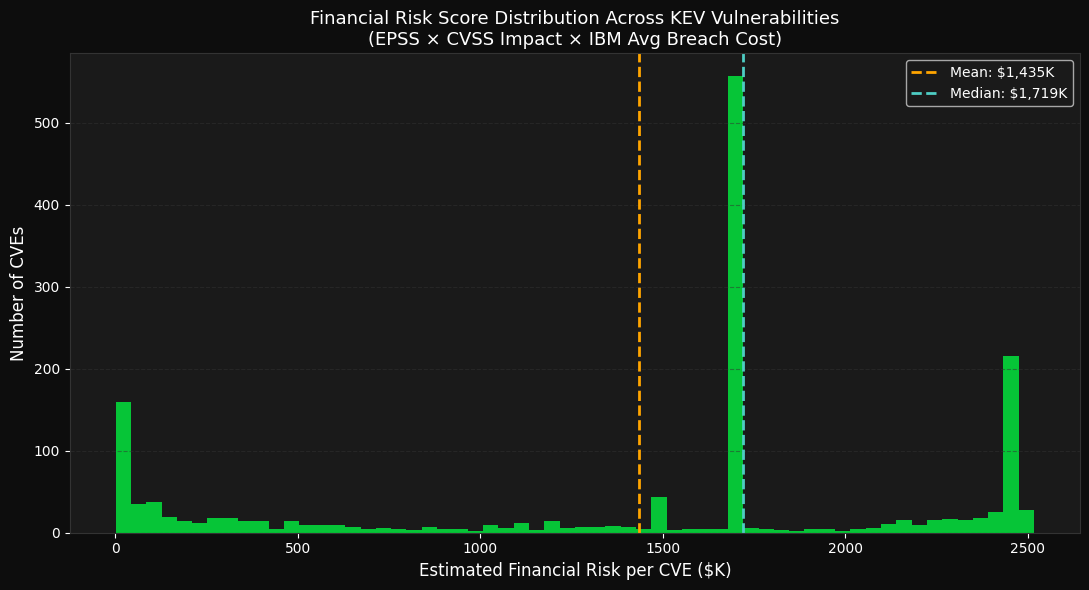

In [51]:
# Histogram: distribution of financial risk scores across all CVEs, with mean and median lines
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

ax.hist(merged['financial_risk_usd'] / 1000, bins=60, color='#00FF41', alpha=0.75, edgecolor='none')
ax.axvline(merged['financial_risk_usd'].mean() / 1000, color='#FFA500', linewidth=2, linestyle='--',
           label=f"Mean: ${merged['financial_risk_usd'].mean()/1000:,.0f}K")
ax.axvline(merged['financial_risk_usd'].median() / 1000, color='#4ECDC4', linewidth=2, linestyle='--',
           label=f"Median: ${merged['financial_risk_usd'].median()/1000:,.0f}K")

ax.set_xlabel('Estimated Financial Risk per CVE ($K)', color='white', fontsize=12)
ax.set_ylabel('Number of CVEs', color='white', fontsize=12)
ax.set_title('Financial Risk Score Distribution Across KEV Vulnerabilities\n(EPSS × CVSS Impact × IBM Avg Breach Cost)',
             color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('financial_risk_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

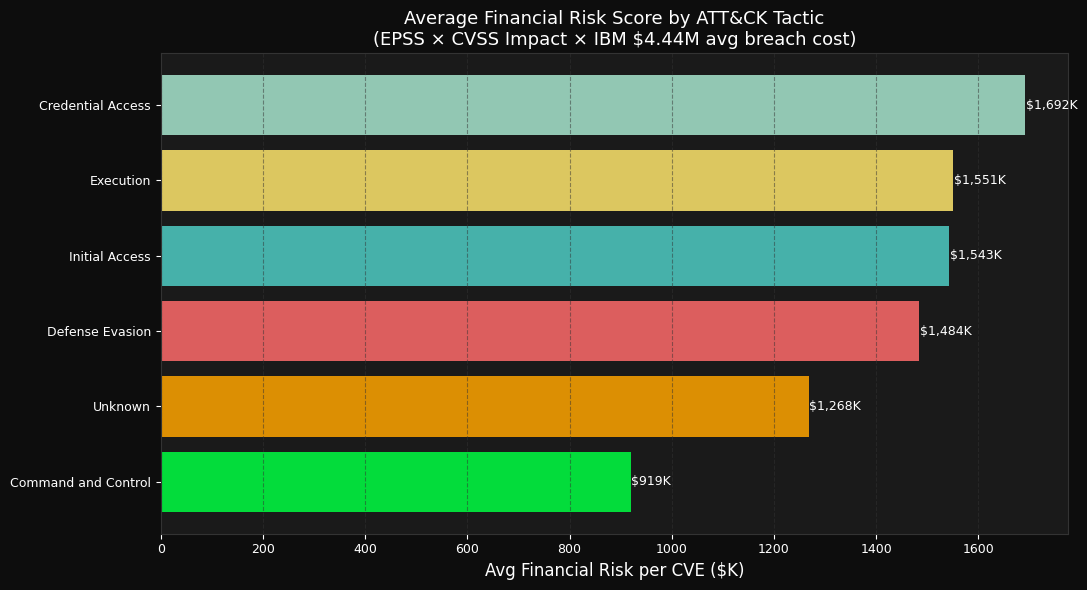

In [56]:
# Bar chart: average financial risk grouped by ATT&CK tactic — shows which tactics cost most
merged['tactic'] = merged['Tactic(s)'].fillna('Unknown').str.split('; ').str[0].str.strip()

tactic_risk = merged.groupby('tactic')['financial_risk_usd'].agg(['mean','sum','count'])
tactic_risk = tactic_risk[tactic_risk['count'] >= 5].sort_values('mean', ascending=True)
tactic_risk.columns = ['avg_risk', 'total_risk', 'count']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

colors = ['#00FF41','#FFA500','#FF6B6B','#4ECDC4','#FFE66D','#A8E6CF','#FF8B94','#C7CEEA']
bars = ax.barh(tactic_risk.index, tactic_risk['avg_risk'] / 1000, color=colors[:len(tactic_risk)], alpha=0.85)

ax.set_xlabel('Avg Financial Risk per CVE ($K)', color='white', fontsize=12)
ax.set_title('Average Financial Risk Score by ATT&CK Tactic\n(EPSS × CVSS Impact × IBM $4.44M avg breach cost)',
             color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
for spine in ax.spines.values(): spine.set_color('#333333')
ax.xaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)

for bar, val in zip(bars, tactic_risk['avg_risk'] / 1000):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:,.0f}K', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.savefig('risk_by_tactic.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [53]:
# Simulate 10,000 years, each with ~50 CVE incidents drawn from the real risk distribution
# 10,000 runs gives a stable estimate of the annual cost range
N_SIMULATIONS = 10_000
AVG_INCIDENTS_PER_YEAR = 50

risk_scores = merged['financial_risk_usd'].dropna().values

total_costs = []
for _ in range(N_SIMULATIONS):
    n_incidents = np.random.poisson(AVG_INCIDENTS_PER_YEAR)
    sampled_costs = np.random.choice(risk_scores, size=n_incidents, replace=True)
    total_costs.append(sampled_costs.sum())

total_costs = np.array(total_costs)

print(f"Monte Carlo complete — {N_SIMULATIONS:,} simulated years")
print(f"Best case (10th pct):  ${np.percentile(total_costs,10)/1e6:.2f}M")
print(f"Expected (mean):       ${np.mean(total_costs)/1e6:.2f}M")
print(f"Worst case (90th pct): ${np.percentile(total_costs,90)/1e6:.2f}M")

Monte Carlo complete — 10,000 simulated years
Best case (10th pct):  $56.84M
Expected (mean):       $71.78M
Worst case (90th pct): $86.94M


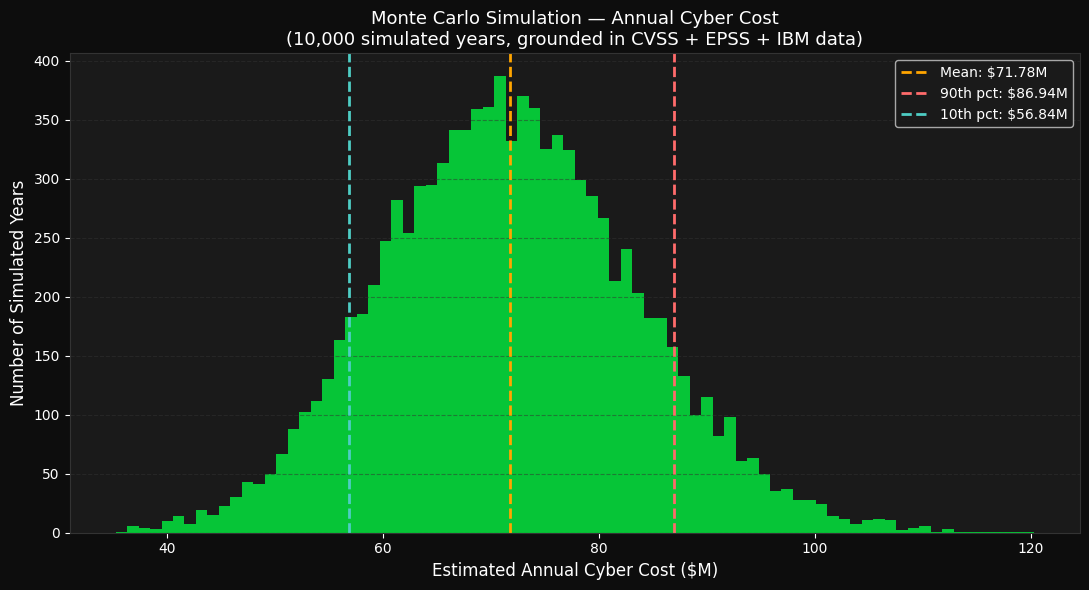

In [54]:
# Histogram: simulated annual cyber cost distribution with 10th, mean, and 90th percentile lines
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

ax.hist(total_costs / 1e6, bins=80, color='#00FF41', alpha=0.75, edgecolor='none')
ax.axvline(np.mean(total_costs)/1e6, color='#FFA500', linewidth=2, linestyle='--',
           label=f"Mean: ${np.mean(total_costs)/1e6:.2f}M")
ax.axvline(np.percentile(total_costs,90)/1e6, color='#FF6B6B', linewidth=2, linestyle='--',
           label=f"90th pct: ${np.percentile(total_costs,90)/1e6:.2f}M")
ax.axvline(np.percentile(total_costs,10)/1e6, color='#4ECDC4', linewidth=2, linestyle='--',
           label=f"10th pct: ${np.percentile(total_costs,10)/1e6:.2f}M")

ax.set_xlabel('Estimated Annual Cyber Cost ($M)', color='white', fontsize=12)
ax.set_ylabel('Number of Simulated Years', color='white', fontsize=12)
ax.set_title(f'Monte Carlo Simulation — Annual Cyber Cost\n({N_SIMULATIONS:,} simulated years, grounded in CVSS + EPSS + IBM data)',
             color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('#333333')
ax.yaxis.grid(True, color='#333333', linestyle='--', alpha=0.5)
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('monte_carlo_final.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

In [57]:
print("=== NOTEBOOK 5 — FINAL SUMMARY ===")
print(f"\nData Sources:")
print(f"  KEV data: sample.xlsx ({len(kev_df)} CVEs)")
print(f"  CVSS + EPSS: cve_epss.csv ({len(epss_df):,} CVEs)")
print(f"  CVEs matched: {matched} ({matched/len(merged):.1%})")
print(f"\nRisk Formula: EPSS × (CVSS Impact ÷ 10) × IBM $4.44M avg breach cost")
print(f"\nModel Performance (from Notebooks 2 & 3):")
print(f"  Logistic Regression accuracy: 93.8%")
print(f"  Random Forest accuracy: 96.9%  ← used for tactic predictions")
print(f"\nMonte Carlo Results ({N_SIMULATIONS:,} simulated years):")
print(f"  Best case  (10th pct): ${np.percentile(total_costs,10)/1e6:.2f}M/year")
print(f"  Expected   (mean):     ${np.mean(total_costs)/1e6:.2f}M/year")
print(f"  Worst case (90th pct): ${np.percentile(total_costs,90)/1e6:.2f}M/year")

=== NOTEBOOK 5 — FINAL SUMMARY ===

Data Sources:
  KEV data: sample.xlsx (1539 CVEs)
  CVSS + EPSS: cve_epss.csv (155,852 CVEs)
  CVEs matched: 989 (64.3%)

Risk Formula: EPSS × (CVSS Impact ÷ 10) × IBM $4.44M avg breach cost

Model Performance (from Notebooks 2 & 3):
  Logistic Regression accuracy: 93.8%
  Random Forest accuracy: 96.9%  ← used for tactic predictions

Monte Carlo Results (10,000 simulated years):
  Best case  (10th pct): $56.84M/year
  Expected   (mean):     $71.78M/year
  Worst case (90th pct): $86.94M/year
